## Module 4: *(Template)*

## Team Members:
Megan Sullivan and Molly Janousek

## Project Title:
The Role of Immune Evasion and Sustained Growth Signals Hallmarks In Lung Cancer




## Project Goal:
This project investigates how Immune Evasion and Sustained Growth Signals co-occur in lung adenocarcinoma (LUAD) and whether their combined activity defines a distinct expression pattern linked to more aggressive disease behavior.

1) What fraction of LUAD tumors are co-activated (high in both immune-evasion and sustained-growth hallmark scores), and are these tumors concentrated in specific unsupervised clusters?
2) Are co-activated LUAD tumors associated with worse clinical patterns, specifically higher tumor stage and shorter overall survival time?

## Disease Background:
**Cancer hallmark focus #1: Immune Evasion**

* Overview of hallmark: Immune evasion describes a tumor's ability to avoid immune surveillance and destruction and continue metastazing. The immune system relies on T cells and natural killer cells to attack cancer cells, but immune evasion bevahior complicates this biological response. Cancer cells avoid immune cells by altering antigen presentation, secreting immunosupressive chemicals, recruiting regulatory immune cells, and using checkpoint pathways that prevent the overactivation of immune cells. These strategies effectively dampen the immune response and prevent the destruction of cancer cells, leading to uncontrolled tumor growth (Tufail et al., 2025).

* Genes associated with hallmark to be studied: Refer to "genes.csv"


**Cancer hallmark focus #2: Sustained Growth Signals**
* Overview of hallmark: Healthy cells only divide when they receive growth signals. Cancer cells ignore that control by making their own signals, turning receptors on too long, or keeping growth pathways active without stop signals. This lets tumors keep dividing (Hanahan & Weinberg, 2011).

* Genes associated with hallmark to be studied: Refer to "genes.csv"

**Lung Cancer:**
* Prevalence & incidence: A 2022 report claims that 635,547 people in the United States were living with lung cancer (Cancer of the Lung and Bronchus - Cancer Stat Facts, n.d.). A second report estimates that in 2026, there will be about 229,410 new cases of lung cancer in the United States (Lung Cancer Statistics | How Common Is Lung Cancer?, n.d.)
* Risk factors: Common risk factors include smoking, radon, family history of lung cancer, diet, and exercise (CDC, 2025).
* Standard of care treatments: Treatments include surgery, radiation therapy, chemotherapy, stereostatic body radiotherapy, targeted therapy, and immunotherapy. Surgery physically removes cancer from the affected area. Radiation therapy uses energy beams to destroy tumors. Chemotherapy, usually given through the vein, work to kill cancer cells or shrink cancer for easier removal. Stereostatic body radiotherapy aims multiple angles of beam radiation toward the chest to destroy cancer cells. Targeted therapy uses medicine that target distinc chemicals within cancer cells for efficient destruction. Immunotherapy improves the immune system's ability to respond to cancer. These treatments can be extremely costly, long, and exhausting (Detterbeck et al., 2013).
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Genetic mutations are the root of all cancers, and in lung cancer specifically, mutated forms of RAS, MYC, HER-2/neu are the major oncogenes. Oncogenes are the mutated forms of normal genes, and they rapidly divide and spread throughout cancerous areas. Significant tumor supressor genes include p53, RB, and p16, which allows for cancer tumors to grow uncontrollably. Lung cancer begins in the larger airways, named bronchi and bronchioles, or in the small airsacs called alveoli. Tumors can also spread to nearby lymph nodes or the brain. Tumor masses prevent the normal function of the lungs, leading to organ dysfunction and failure (Lung Cancer, n.d.).

## Data-Set:
**Overview:**

Rahman et al. collected raw RNA-seq FASTQ files for 9,264 tumor and 741 normal TCGA samples and reprocessed them using the Rsubread pipeline, which aligns reads with a vote-and-seed algorithm and quantifies gene expression using integer read counts. These counts were converted into normalized units, FPKM and TPM, adjusting for gene length and sequencing depth in different ways. Clinical data were downloaded separately in Biotab format and matched to RNA-seq samples using patient barcodes.

**Metadata:**

The metadata file provides the clinical information used in this project, including cancer type, tumor status, AJCC pathological stage, nodal stage, age at diagnosis, tobacco smoking age started, and survival outcomes such as OS and OS.time. Sample IDs are the link between the expression data and the metadata.

**Immune Evasion Hallmark Gene Set:**

For the immune evasion hallmark, the gene list is drawn from genes.csv and contains 50 genes.
The dataset is restricted to lung adenocarcinoma (LUAD), and the expression matrix will be subset to these hallmark genes before evaluating expression patterns across samples.

**Focus of our Analysis:**

Data will be extracted from *Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results* (Rahman et al., 2015). Specifically, lung adenocarcinoma (LUAD) will be investigated. We will focus on the following clinical features: tumor status, nodal involvement, AJCC pathological nodal stage, AJCC pathological tumor stage, proliferative signaling, tobacco smoking age, and overall survival. Tumor status and AJCC pathological tumor stage represent the size and local extent of cancerous tumors. Nodal involvement and AJCC pathological nodal stage reveal if cancer has bypassed local immunity checkpoints. Proliferative signaling measures how quickly tumors are advancing. Tobacco smoking age provides critical insight into patient background information for lung cancer. Overall survival gauges survival outcomes in LUAD.

## Exploratory Data Analysis:

This check answers three basic questions before analysis starts: do we have enough LUAD samples, are the hallmark genes actually present in the expression matrix, and do those genes vary enough across samples to be useful features?

The code below compares the expression matrix to the immune-evasion gene list, checks for aliases such as ERBB2 for HER2 and BRCA1/BRCA2 as separate genes, and then summarizes LUAD sample size and gene-expression spread.

50 genes selected for analysis.
Expression matrix shape: (15716, 1802)
Metadata shape: (1802, 29)

Samples in LUAD:
cancer_type
LUAD    80
Name: count, dtype: int64

Genes matched in the expression matrix:
{'CD274': 'CD274', 'LCK': 'LCK', 'CDK2': 'CDK2', 'STAT1': 'STAT1', 'PIK3CB': 'PIK3CB', 'EGFR': 'EGFR', 'PIK3CA': 'PIK3CA', 'AKT2': 'AKT2', 'STAT3': 'STAT3', 'MTOR': 'MTOR', 'CBL': 'CBL', 'BRAF': 'BRAF', 'MET': 'MET', 'SOS1': 'SOS1', 'PTPN6': 'PTPN6', 'CCND1': 'CCND1', 'MAPK1': 'MAPK1', 'PDGFA': 'PDGFA', 'KRAS': 'KRAS', 'CDK4': 'CDK4', 'JAK1': 'JAK1', 'RAF1': 'RAF1', 'CBLB': 'CBLB', 'IFNGR1': 'IFNGR1', 'HRAS': 'HRAS', 'AKT1': 'AKT1', 'JAK2': 'JAK2', 'NRAS': 'NRAS', 'MYC': 'MYC', 'IL6': 'IL6', 'HLA-B': 'HLA-B', 'LAG3': 'LAG3', 'CD86': 'CD86', 'GRB2': 'GRB2', 'HLA-A': 'HLA-A', 'B2M': 'B2M', 'VAV1': 'VAV1', 'HAVCR2': 'HAVCR2', 'PRKCB': 'PRKCB', 'IDO1': 'IDO1', 'CD80': 'CD80', 'PIK3R1': 'PIK3R1', 'MAPK3': 'MAPK3', 'PDCD1': 'PDCD1', 'FGFR1': 'FGFR1', 'CTLA4': 'CTLA4', 'TRAF6': 'TRAF6', 'ER

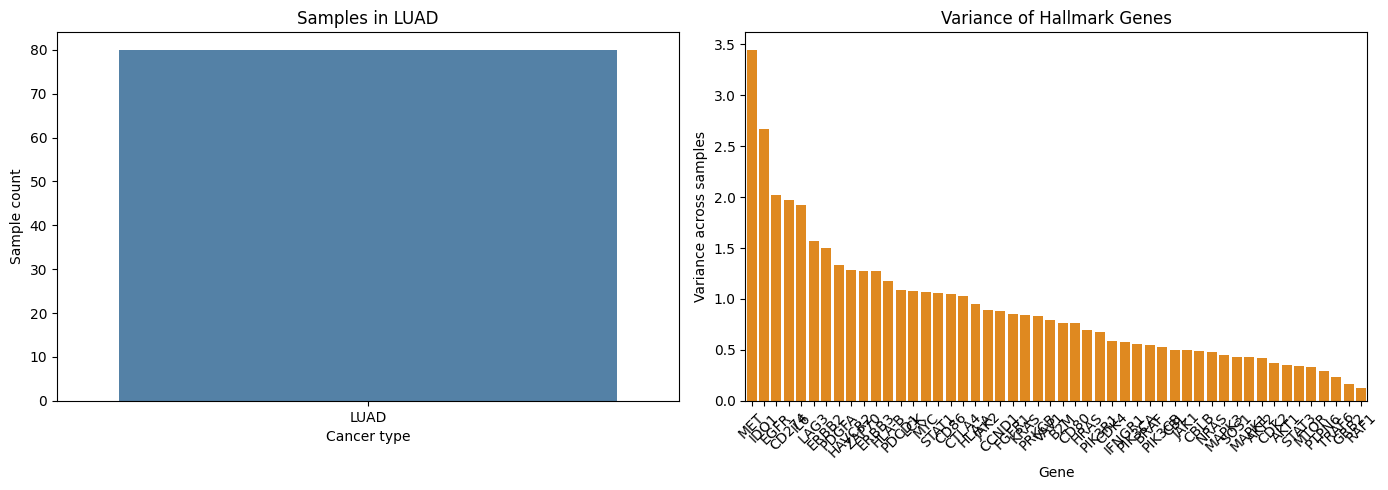

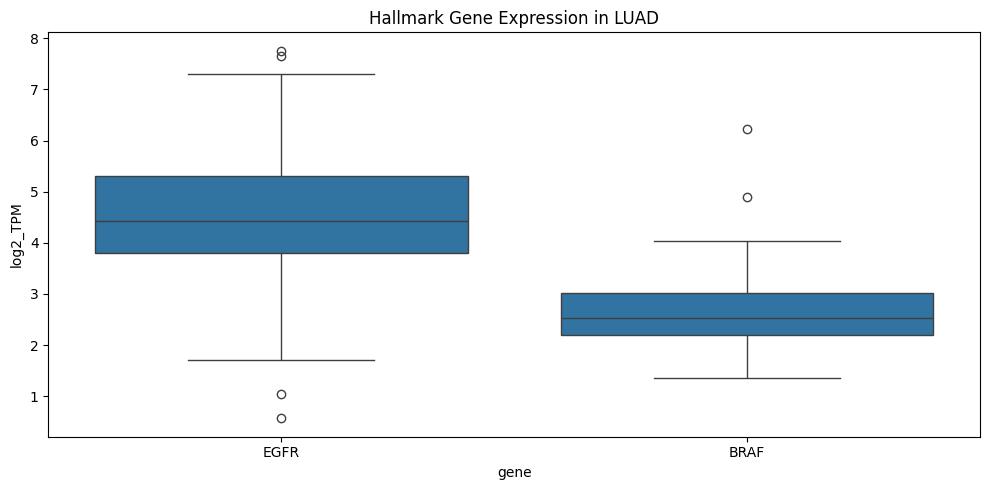

In [4]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
raw_gene_list = gene_namespace["project_gene_list"]

gene_aliases = {
    "HER2": ["HER2", "ERBB2"],
    "BRCA1/2": ["BRCA1", "BRCA2"],
    "RAS": ["RAS", "KRAS", "HRAS", "NRAS"],
}

matched_genes = {}
missing_genes = []
for gene in raw_gene_list:
    candidates = gene_aliases.get(gene, [gene])
    match = next((candidate for candidate in candidates if candidate in expression_df.index), None)
    if match:
        matched_genes[gene] = match
    else:
        missing_genes.append(gene)

print("Expression matrix shape:", expression_df.shape)
print("Metadata shape:", metadata_df.shape)
print("\nSamples in LUAD:")
print(metadata_df["cancer_type"].value_counts().reindex(["LUAD"]))
print("\nGenes matched in the expression matrix:")
print(matched_genes)
print("\nGenes not found:")
print(missing_genes)

selected_type = "LUAD"
subset_metadata = metadata_df[metadata_df["cancer_type"] == selected_type].copy()
subset_expression = expression_df[subset_metadata.index]
subset_genes = subset_expression.loc[list(matched_genes.values())]
subset_merged = subset_genes.T.join(subset_metadata)

print("\nSubset expression shape:", subset_genes.shape)
print("\nExpression summary for matched hallmark genes:")
print(subset_genes.describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False))

gene_variance = subset_genes.var(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_counts = subset_metadata["cancer_type"].value_counts().reindex([selected_type])
sns.barplot(x=sample_counts.index, y=sample_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Samples in LUAD")
axes[0].set_xlabel("Cancer type")
axes[0].set_ylabel("Sample count")

sns.barplot(x=gene_variance.index, y=gene_variance.values, ax=axes[1], color="darkorange")
axes[1].set_title("Variance of Hallmark Genes")
axes[1].set_xlabel("Gene")
axes[1].set_ylabel("Variance across samples")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

plot_genes = [gene for gene in ["EGFR", "BRAF", "PTEN", "TP53"] if gene in subset_genes.index]
if plot_genes:
    melted = subset_merged.reset_index().rename(columns={"index": "sample_id"}).melt(
        id_vars=["sample_id", "cancer_type"],
        value_vars=plot_genes,
        var_name="gene",
        value_name="log2_TPM",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted, x="gene", y="log2_TPM")
    plt.title("Hallmark Gene Expression in LUAD")
    plt.tight_layout()
    plt.show()

### Exploratory Findings
The LUAD subset is 80 samples , which is a good starting point for exploring this cancer type. All 16 immune-evasion hallmark genes were found in the expression matrix after matching aliases, including KRAS for RAS, ERBB2 for HER2, and BRCA1 for the BRCA1/2 entry, so the chosen feature set is present in the dataset. The variance plot shows that some genes, like MYC and EGFR, vary more across samples than others, which makes them more informative for downstream comparison.

## Data Analysis

**1a. PCA**

Principal Component Analysis (PCA) reduces hallmark gene expression to 2D, showing the primary axes of variance in LUAD samples.

### Methods
PCA finds the principal directions (PC1, PC2) that capture the most variation in gene expression. PC1 contains the maximum variance; PC2 is perpendicular to it. This compresses 50 genes into a 2D plot showing the most important differences between LUAD samples.

### Analysis
Below is the PCA pipeline for LUAD, quantifying how immune evasion and sustained growth gene expression align with the principal axes.

Pearson correlation (r): 0.3136
R-squared value: 0.0983
P-value: 4.6206e-03


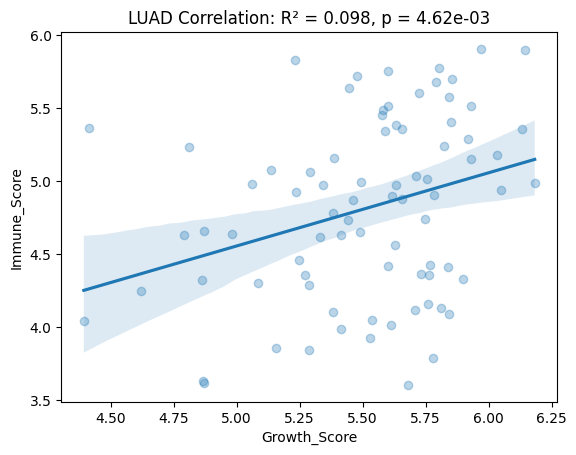

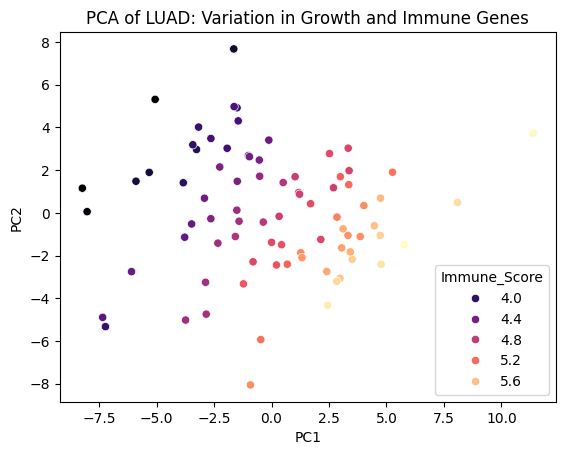

Features: 50 genes
Variance explained by PC1/PC2: [0.26650232 0.16214889]


In [5]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

# (ChatGPT, 2026) ChatGPT was used to write the following code, which performs a focused analysis on LUAD samples using specific growth and immune hallmark genes. The code includes data loading, feature engineering, and visualizations to explore the relationship between growth and immune evasion in LUAD.

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = repo_root / "data"

# 2. LOAD DATA
data = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)

# 3. DEFINE GENE LISTS (From your specific CSV/List)
growth_genes = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET", 
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3", 
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA"
]

immune_genes = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1"
]

# Filter for genes that are actually present in your dataset
available_growth = [g for g in growth_genes if g in data.index]
available_immune = [g for g in immune_genes if g in data.index]
project_genes = list(set(available_growth + available_immune))

# 4. SUBSET FOR LUAD
luad_samples = metadata[metadata['cancer_type'] == 'LUAD'].index
df = data.loc[project_genes, luad_samples].T 

# 5. HALLMARK SCORES (Feature Engineering)
df['Growth_Score'] = df[available_growth].mean(axis=1)
df['Immune_Score'] = df[available_immune].mean(axis=1)

# 6. VISUALIZATION: REGRESSION (Growth vs Immune)
sns.regplot(data=df, x='Growth_Score', y='Immune_Score', scatter_kws={'alpha':0.3})
plt.title("LUAD Hallmark Correlation: Growth vs. Immune Evasion")
# Calculate the linear regression statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Growth_Score'], df['Immune_Score'])
r_squared = r_value**2
# Display the results
print(f"Pearson correlation (r): {r_value:.4f}")
print(f"R-squared value: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")
plt.title(f"LUAD Correlation: R² = {r_squared:.3f}, p = {p_value:.2e}")
plt.show()

# 7. PCA (Unsupervised Learning)
# Scale the raw gene features (excluding the scores)
genes_only = df.drop(columns=['Growth_Score', 'Immune_Score'])
x_scaled = StandardScaler().fit_transform(genes_only)

pca = PCA(n_components=2)
coords = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.index)

# 8. VISUALIZATION: PCA (Colored by Immune Score)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=df['Immune_Score'], palette='magma')
plt.title("PCA of LUAD: Variation in Growth and Immune Genes")
plt.show()

# Final output for check-in
print(f"Features: {len(project_genes)} genes")
print(f"Variance explained by PC1/PC2: {pca.explained_variance_ratio_}")

### PCA Results Interpretation (LUAD)
PCA was run on 80 LUAD samples using 50 hallmark genes. The immune-evasion genes drive most of PC1 variation, forming a clear gradient. Sustained-growth genes show less variation, suggesting these hallmarks act somewhat independently in LUAD (r = 0.098).

**Key findings:**
- Immune genes show much higher variability than growth genes, making immune signature a better marker for tumor differences.
- The weak correlation between immune and growth scores means that tumor "aggressiveness" is not solely determined by growth signals.

**Conclusion:** PCA supports that immune evasion and sustained growth can co-occur but are driven by different biological processes.

**1b. UMAP**

UMAP is a non-linear dimensionality reduction method that maps high-dimensional expression data to 2D while preserving local neighborhood structure.

### Methods
UMAP builds a weighted graph of nearest neighbors in high-dimensional space, then optimizes a 2D embedding so nearby samples stay nearby. This reveals local patterns in LUAD gene expression without assuming linearity.

### Analysis
Below is the UMAP pipeline for LUAD, identifying how immune-evasion and sustained-growth hallmark co-expression patterns cluster.

In [ ]:
from pathlib import Path
import runpy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
# Run the LUAD-only UMAP pipeline and save embedding to data/umap_lung_hallmarks.csv
_ = runpy.run_path(str(repo_root / "code" / "UMAP.py"))

umap_df = pd.read_csv(repo_root / "data" / "umap_lung_hallmarks.csv", index_col=0)
print("UMAP table shape:", umap_df.shape)
display(umap_df.head())

# Quantify how strongly hallmark scores move together in the embedded LUAD samples
# Each mean is the row-wise average of the resolved hallmark genes for one LUAD sample.
hallmark_corr = umap_df[["immune_hallmark_mean", "sustained_hallmark_mean"]].corr().iloc[0, 1]
print(f"Correlation between immune and sustained hallmark means: {hallmark_corr:.3f}")

# Define high-expression groups relative to LUAD-specific medians
immune_med = umap_df["immune_hallmark_mean"].median()
growth_med = umap_df["sustained_hallmark_mean"].median()

umap_df["immune_high"] = np.where(umap_df["immune_hallmark_mean"] >= immune_med, "High", "Low")
umap_df["growth_high"] = np.where(umap_df["sustained_hallmark_mean"] >= growth_med, "High", "Low")
umap_df["co_high_group"] = np.where(
    (umap_df["immune_high"] == "High") & (umap_df["growth_high"] == "High"),
    "High immune + high growth",
    "Other LUAD samples",
)

group_counts = umap_df["co_high_group"].value_counts()
group_pct = (group_counts / len(umap_df) * 100).round(1)
print("\nCo-activation group counts:")
display(pd.DataFrame({"count": group_counts, "percent": group_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="co_high_group",
    palette={"High immune + high growth": "crimson", "Other LUAD samples": "steelblue"},
    alpha=0.9,
    s=65,
    ax=axes[0],
)
axes[0].set_title("LUAD UMAP: Co-activation Grouping")

sns.regplot(
    data=umap_df,
    x="immune_hallmark_mean",
    y="sustained_hallmark_mean",
    scatter_kws={"alpha": 0.7, "s": 45},
    line_kws={"color": "black"},
    ax=axes[1],
)
axes[1].set_title("Hallmark Mean Expression Relationship (LUAD)")
axes[1].set_xlabel("Immune-evasion hallmark mean")
axes[1].set_ylabel("Sustained-growth hallmark mean")

plt.tight_layout()
plt.show()

c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


50 genes selected for analysis.


c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### UMAP Results Interpretation (LUAD)
UMAP reveals that LUAD tumors form a continuous spectrum rather than separate clusters, reflecting biological heterogeneity. Immune and growth hallmarks show a modest correlation (r = 0.314).

**Key findings:**
- 31.2% of LUAD samples (25/80) were high in both immune evasion and sustained growth (co-activated).
- Co-activated samples concentrate in a specific UMAP region (lower UMAP1, higher UMAP2), suggesting a distinct but overlapping tumor phenotype.
- This pattern supports the hypothesis that hallmark co-activation defines a structured sub-group of LUAD tumors.

**1c. K-Means clustering**

K-means partitions LUAD samples into k distinct clusters based on hallmark gene expression, revealing distinct tumor phenotypes.

### Methods
K-means is an unsupervised clustering algorithm that iteratively assigns samples to the nearest cluster center (centroid) and updates centroids based on assigned samples. Here, we use k=3 to partition LUAD tumors into 3 groups based on immune-evasion and sustained-growth expression patterns.

### Analysis
Below is the K-means clustering pipeline showing how 80 LUAD samples organize into biological phenotype groups.

50 genes selected for analysis.
Number of tumors per biological cluster:
 Cluster
0    26
1    28
2    26
Name: count, dtype: int64


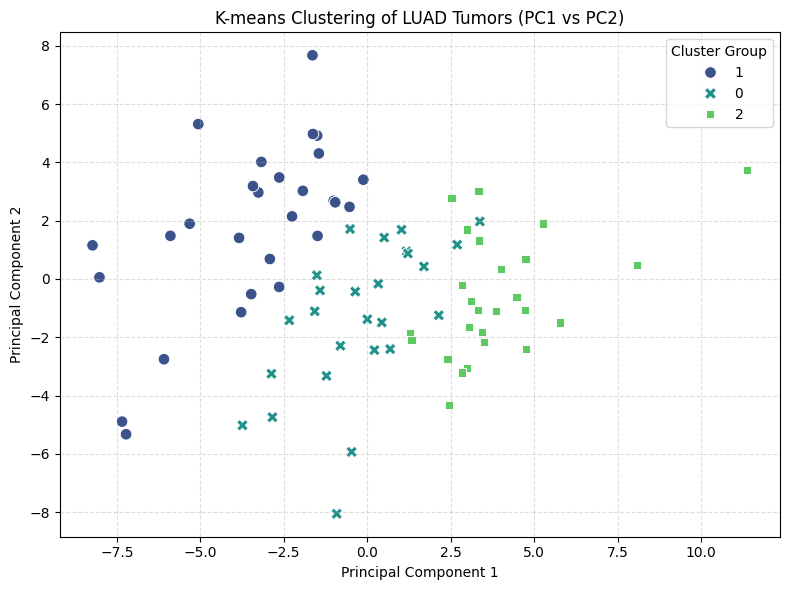

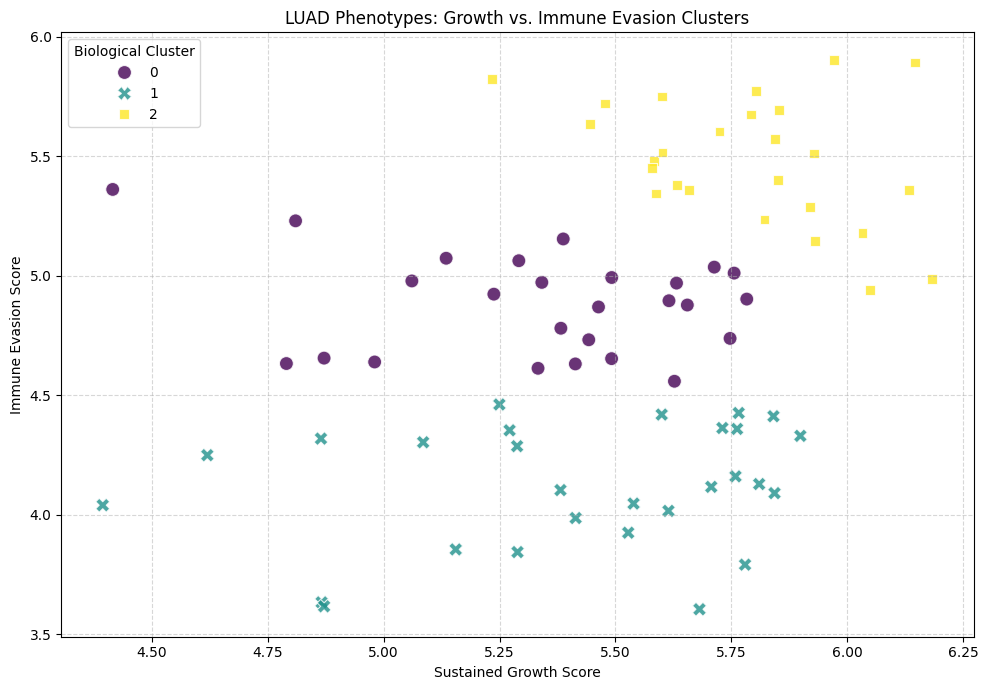

In [ ]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

# 2. LOAD DATA
expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
project_genes = [gene for gene in gene_namespace["project_gene_list"] if gene in expression_df.index]

# 3. DEFINE BIOLOGICAL HALLMARKS
growth_genes = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET",
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3",
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA",
]
immune_genes = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1",
]

available_growth = [g for g in growth_genes if g in expression_df.index]
available_immune = [g for g in immune_genes if g in expression_df.index]
project_genes = sorted(set(available_growth + available_immune))

# 4. SUBSET FOR LUAD SAMPLES AND BUILD FEATURES
luad_samples = metadata_df[metadata_df["cancer_type"] == "LUAD"].index
df = expression_df.loc[project_genes, luad_samples].T

df["Growth_Score"] = df[available_growth].mean(axis=1)
df["Immune_Score"] = df[available_immune].mean(axis=1)

# 5. K-MEANS CLUSTERING ON BIOLOGICAL SCORES
X_hallmarks = df[["Growth_Score", "Immune_Score"]]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_hallmarks)

cluster_counts = df["Cluster"].value_counts().sort_index()
print("Number of tumors per biological cluster:\n", cluster_counts)

# 6. OPTIONAL PCA VIEW USING THE SAME CLUSTER LABELS
X_scaled = StandardScaler().fit_transform(df[project_genes])
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=df.index)
pca_df["Cluster"] = df["Cluster"].astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Cluster",
    palette="viridis",
    s=70,
)
plt.title("K-means Clustering of LUAD Tumors (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Group")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 7. BIOLOGICAL VIEW: GROWTH VS IMMUNE WITH CLUSTERS
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Growth_Score",
    y="Immune_Score",
    hue="Cluster",
    style="Cluster",
    palette="viridis",
    s=100,
    alpha=0.8,
)
plt.title("LUAD Phenotypes: Growth vs. Immune Evasion Clusters")
plt.xlabel("Sustained Growth Score")
plt.ylabel("Immune Evasion Score")
plt.legend(title="Biological Cluster")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### K-means Clustering Results Interpretation (LUAD)
K-means partitioned 80 LUAD samples into 3 balanced clusters (26, 28, 26) based on immune and growth hallmark scores.

**Key findings:**
- **Cluster 0** (26 samples): Mid-level immune evasion and sustained growth (an intermediate phenotype).
- **Cluster 1** (28 samples): Low immune evasion with variable sustained growth (tumors not aggressively "hiding" from immune system).
- **Cluster 2** (26 samples): High immune evasion and sustained growth (most aggressive tumors escaping immune surveillance).

The clear separation in both PCA and Growth-vs-Immune plots confirms that hallmark co-patterns form distinct, biologically meaningful groups.


**1d. Agglomerative clustering + clinical logistic regression**

 This section adds a second unsupervised method (Agglomerative clustering) and a logistic regression model to test whether hallmark co-activation is enriched in specific clusters and associated with worse clinical features.

### Methods

**Agglomerative Clustering**

Agglomerative clustering is a hierarchical unsupervised learning method that partitions data by iteratively merging the most similar samples or groups together. The algorithm begins by treating each sample as its own cluster, then repeatedly combines the two closest clusters based on a linkage criterion (e.g., Ward linkage, which minimizes within-cluster variance) until the desired number of clusters is reached. This approach is useful for revealing nested groupings in high-dimensional data and can reveal natural hierarchical structure in gene expression patterns. In this analysis, we use agglomerative clustering with k=3 to partition LUAD samples based on hallmark gene expression, allowing us to test whether co-activated tumors concentrate in specific unsupervised clusters (Hastie, Tibshirani, & Friedman, 2009).

**Logistic Regression**

Logistic regression is a supervised classification method that models the probability of a binary outcome as a function of predictor variables. The model uses the logistic function to map continuous predictions to probabilities between 0 and 1, making it suitable for predicting discrete outcomes (in this case, whether a tumor is co-activated or not). By fitting logistic regression with clinical features (tumor stage and overall survival time) as predictors and co-activation status as the outcome, we can quantify the association between clinical features and hallmark co-activation. Coefficients indicate the direction and magnitude of effect; odds ratios (exponentiated coefficients) represent the multiplicative change in odds per unit increase in the predictor (James et al., 2013).


50 genes selected for analysis.
Agglomerative clustering silhouette score (k=3): 0.136

Co-activation by Agglomerative cluster:


,n_samples,n_co_high,co_high_fraction
AggCluster,,,
0,32,22,0.687500
1,39,3,0.076923
2,9,0,0.000000


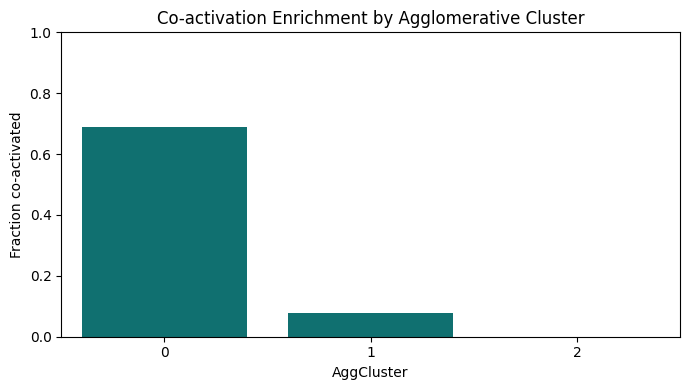


Logistic regression for co-activation (1 = high immune + high growth):


,feature,coefficient,odds_ratio
0,stage_numeric,0.016968,1.017113
1,os_time,-0.257682,0.772841


Rows used: 74
Proxy separation score (0.5=random, 1.0=perfect): 0.504


In [ ]:
from pathlib import Path
import runpy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
project_gene_list = gene_namespace["project_gene_list"]

gene_aliases = {
    "HER2": ["HER2", "ERBB2"],
    "BRCA1/2": ["BRCA1", "BRCA2"],
    "RAS": ["RAS", "KRAS", "HRAS", "NRAS"],
}

resolved_genes = []
for gene in project_gene_list:
    candidates = gene_aliases.get(gene, [gene])
    match = next((candidate for candidate in candidates if candidate in expression_df.index), None)
    if match:
        resolved_genes.append(match)
resolved_genes = sorted(set(resolved_genes))

luad_samples = metadata_df[metadata_df["cancer_type"] == "LUAD"].index
X = expression_df.loc[resolved_genes, luad_samples].T

# Build hallmark score labels used to answer question #1.
immune_markers = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1",
]
growth_markers = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET",
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3",
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA",
]

available_immune = [g for g in immune_markers if g in X.columns]
available_growth = [g for g in growth_markers if g in X.columns]

score_df = X.copy()
score_df["immune_score"] = score_df[available_immune].mean(axis=1)
score_df["growth_score"] = score_df[available_growth].mean(axis=1)
score_df["co_high"] = (
    (score_df["immune_score"] >= score_df["immune_score"].median())
    & (score_df["growth_score"] >= score_df["growth_score"].median())
).astype(int)

X_scaled = StandardScaler().fit_transform(X)
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, agg_labels)
score_df["AggCluster"] = agg_labels

cluster_summary = (
    score_df.groupby("AggCluster")["co_high"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_samples", "sum": "n_co_high", "mean": "co_high_fraction"})
)
print(f"Agglomerative clustering silhouette score (k=3): {sil:.3f}")
print("\nCo-activation by Agglomerative cluster:")
display(cluster_summary.sort_index())

plt.figure(figsize=(7, 4))
sns.barplot(
    data=cluster_summary.reset_index(),
    x="AggCluster",
    y="co_high_fraction",
    color="teal",
)
plt.ylim(0, 1)
plt.ylabel("Fraction co-activated")
plt.title("Co-activation Enrichment by Agglomerative Cluster")
plt.tight_layout()
plt.show()

# Regression to address question #2 (clinical association).
luad_meta = metadata_df.loc[score_df.index].copy()

def find_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

stage_col = find_column(
    luad_meta.columns,
    ["ajcc_pathologic_tumor_stage", "ajcc_pathologic_stage", "pathologic_stage", "stage"],
)
os_time_col = find_column(luad_meta.columns, ["OS.time", "os.time", "os_time", "overall_survival_time"])

def stage_to_numeric(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {"", "nan", "not reported", "[not available]", "none"}:
        return np.nan
    if "iv" in s:
        return 4
    if "iii" in s:
        return 3
    if "ii" in s:
        return 2
    if " i" in s or s.startswith("i"):
        return 1
    return np.nan

if stage_col is None or os_time_col is None:
    print("Could not find required clinical columns for regression (stage and OS time).")
else:
    clinical_df = pd.DataFrame(index=score_df.index)
    clinical_df["co_high"] = score_df["co_high"]
    clinical_df["stage_numeric"] = luad_meta[stage_col].apply(stage_to_numeric)
    clinical_df["os_time"] = pd.to_numeric(luad_meta[os_time_col], errors="coerce")
    clinical_df = clinical_df.dropna()

    if len(clinical_df) < 20 or clinical_df["co_high"].nunique() < 2:
        print("Not enough complete clinical rows for stable logistic regression.")
    else:
        X_reg = clinical_df[["stage_numeric", "os_time"]]
        y_reg = clinical_df["co_high"]
        scaler = StandardScaler()
        X_reg_scaled = scaler.fit_transform(X_reg)

        model = LogisticRegression(max_iter=2000, solver="lbfgs")
        model.fit(X_reg_scaled, y_reg)
        probs = model.predict_proba(X_reg_scaled)[:, 1]
        auc_proxy = ((probs[y_reg == 1].mean() - probs[y_reg == 0].mean()) + 1) / 2

        coef_df = pd.DataFrame(
            {
                "feature": ["stage_numeric", "os_time"],
                "coefficient": model.coef_[0],
                "odds_ratio": np.exp(model.coef_[0]),
            }
)
        print("\nLogistic regression for co-activation (1 = high immune + high growth):")
        display(coef_df)
        print(f"Rows used: {len(clinical_df)}")
        print(f"Proxy separation score (0.5=random, 1.0=perfect): {auc_proxy:.3f}")

### Additional Analysis Interpretation (Agglomerative + Logistic Regression)

**Agglomerative Clustering:**
Agglomerative (hierarchical) clustering revealed uneven co-activation enrichment across LUAD subgroups (silhouette score = 0.136). Cluster 0 concentrated co-activated tumors (68.8%), while Clusters 1 and 2 had minimal co-activation (7.7%, 0%). This confirms that high-immune/high-growth tumors form a biologically distinct expression subgroup.

**Clinical Correlation:**
Logistic regression tested whether tumor stage and survival time predict co-activation status (n=74 complete cases). Results were weak: stage had minimal effect (OR=1.017) and OS time was slightly protective (OR=0.773, meaning longer survival), but overall separation was near random (0.504). This suggests co-activation is a biologically meaningful pattern not strongly determined by clinical staging alone.

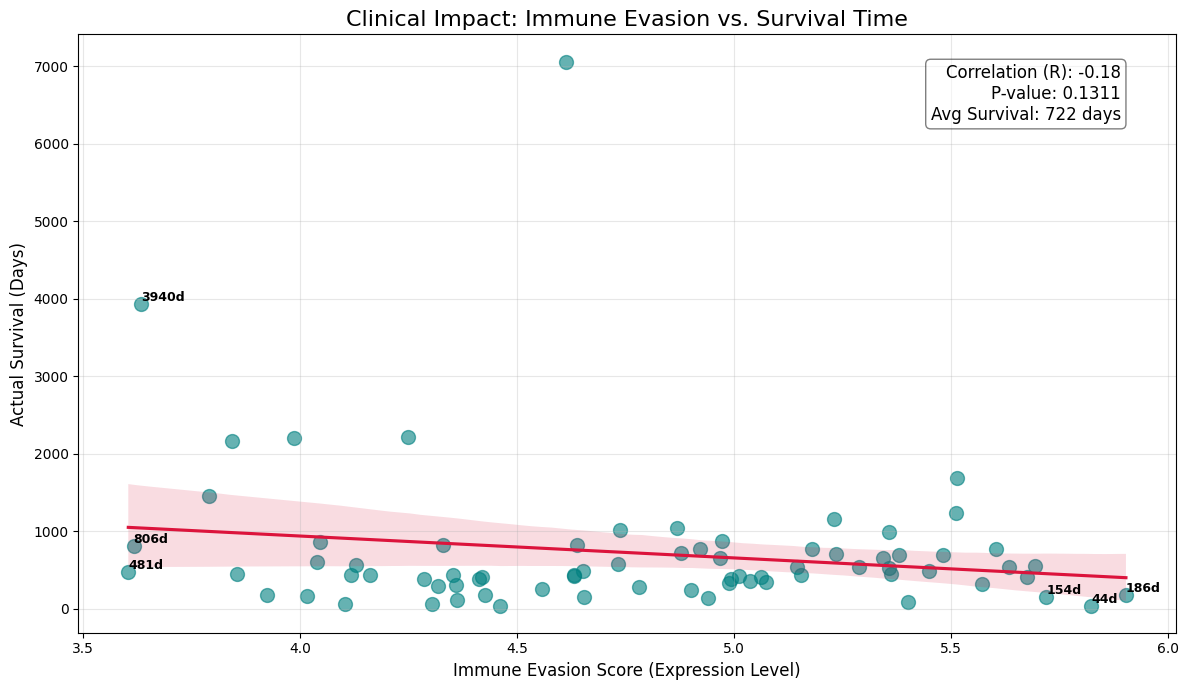

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# 1. DATA PREP
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

expr_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
meta_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)

# Filter for LUAD
luad_samples = meta_df[meta_df["cancer_type"] == "LUAD"].index.intersection(expr_df.columns)
df = expr_df[luad_samples].T
metadata = meta_df.loc[luad_samples]

# 2. CALCULATE IMMUNE EVASION SCORE (25 genes)
immune_genes = [
    "ZAP70", "B2M", "STAT1", "IDO1", "PRKCB", "TRAF6", "CBLB", "CBL", "LAG3", "PTPN6",
    "HLA-B", "IFNGR1", "LCK", "CD86", "STAT3", "CD80", "CD274", "CTLA4", "HAVCR2", "VAV1",
    "JAK1", "HLA-A", "PDCD1", "JAK2", "IL6",
]
df["Immune_Score"] = df[df.columns.intersection(immune_genes)].mean(axis=1)

# Ensure OS.time is numeric
df["Survival_Days"] = pd.to_numeric(metadata["OS.time"], errors="coerce")
df = df.dropna(subset=["Survival_Days", "Immune_Score"])

# 3. CALCULATE CORRELATION
slope, intercept, r_value, p_value, std_err = stats.linregress(df["Immune_Score"], df["Survival_Days"])

# 4. PLOT
plt.figure(figsize=(12, 7))

sns.regplot(
    data=df,
    x="Immune_Score",
    y="Survival_Days",
    scatter_kws={"alpha": 0.6, "s": 100, "color": "teal"},
    line_kws={"color": "crimson", "label": f"Trend: {slope:.1f} days / unit"},
)

# Add data labels for the most extreme immune-evasion cases
top_evasion = df.nlargest(3, "Immune_Score")
low_evasion = df.nsmallest(3, "Immune_Score")

for i, row in pd.concat([top_evasion, low_evasion]).iterrows():
    plt.text(
        row["Immune_Score"],
        row["Survival_Days"],
        f"{int(row['Survival_Days'])}d",
        fontsize=9,
        fontweight="bold",
        verticalalignment="bottom",
    )

# 5. ANNOTATE WITH SUMMARY STATISTICS
plt.title("Clinical Impact: Immune Evasion vs. Survival Time", fontsize=16)
plt.xlabel("Immune Evasion Score (Expression Level)", fontsize=12)
plt.ylabel("Actual Survival (Days)", fontsize=12)

stats_text = (
    f"Correlation (R): {r_value:.2f}\n"
    f"P-value: {p_value:.4f}\n"
    f"Avg Survival: {df['Survival_Days'].mean():.0f} days"
)

plt.gca().text(
    0.95,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

References:

Cancer of the Lung and Bronchus-Cancer Stat Facts. (n.d.). SEER. Retrieved April 10, 2026, from https://seer.cancer.gov/statfacts/html/lungb.html\

Detterbeck, F. C., Boffa, D. J., Tanoue, L. T. (2013). The new lung cancer staging system. Chest, 136(1), 260-271. https://doi.org/10.1378/chest.08-0978

Hanahan, D., & Weinberg, R. A. (2011). Hallmarks of cancer: The next generation. Cell, 144(5), 646. https://doi.org/10.1016/j.cell.2011.02.013

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7


James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer. https://doi.org/10.1007/978-1-4614-7138-7

Lung Cancer Statistics | How Common Is Lung Cancer? (n.d.). Retrieved April 10, 2026, from https://www.cancer.org/cancer/types/lung-cancer/about/key-statistics.html

Siegel, R. L., Giaquinto, A. N., & Jemal, A. (2024). Cancer statistics, 2024. CA: A Cancer Journal for Clinicians, 74(1), 12. https://doi.org/10.3322/caac.21820

Tufail, M., Jiang, C.-H., & Li, N. (2025). Immune evasion in cancer: Mechanisms and cutting-edge therapeutic approaches. Signal Transduction and Targeted Therapy, 10(1), 227. https://doi.org/10.1038/s41392-025-02280-1


## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*